In [ ]:
# Install scanpy and ensure numpy compatibility, then restart
%%capture
!uv pip install numpy pandas matplotlib scanpy

In [ ]:
# libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action='ignore', category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

In [ ]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set the working directory (adjust the path as needed)
working_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project"
os.chdir(working_dir)

In [ ]:
# project tree
for root, dirs, files in os.walk("."):
    level = root.count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for file in files:
        print("  " * (level + 1) + file)

./
  notebook/
    nb04_integration.ipynb
    nb01_ds_anndata.ipynb
    nb02_qc_.ipynb
    nb03_dimred.ipynb
  data /
    raw/
      ncov_pbmc_15.h5
      ncov_pbmc_16.h5
      normal_pbmc_14.h5
      normal_pbmc_5.h5
      ncov_pbmc_1.h5
      normal_pbmc_19.h5
      ncov_pbmc_17.h5
      normal_pbmc_13.h5
      data/
        filtered/
          drosophila_file.h5ad
    integrated /
    filtered/
      drosophila_qc_preprocessed.h5ad
  result /


In [ ]:
# Load the AnnData object
adata = sc.read_h5ad('data /filtered/drosophila_qc_preprocessed.h5ad')

# Print unique sample names before mapping to verify
print('Original unique sample names:', adata.obs['sample'].unique())

# Create a mapping dictionary (for reference, as sample column seems pre-mapped)
drosophila_sample_map = {
    'ncov_pbmc_1': 'Female_Cocaine_1',
    'ncov_pbmc_15': 'Female_Cocaine_2',
    'ncov_pbmc_16': 'Male_Cocaine_1',
    'ncov_pbmc_17': 'Male_Cocaine_2',
    'normal_pbmc_5': 'Female_Sucrose_1',
    'normal_pbmc_13': 'Female_Sucrose_2',
    'normal_pbmc_14': 'Male_Sucrose_1',
    'normal_pbmc_19': 'Male_Sucrose_2'
}

# 1. The 'sample' column already contains the desired names, so skipping re-mapping.
# If original names were present, the line below would be used:
# adata.obs['sample'] = adata.obs['sample'].map(drosophila_sample_map)

# 2. Update the treatment/type column based on the existing 'sample' column
adata.obs['type'] = adata.obs['sample'].apply(
    lambda x: 'Cocaine' if 'Cocaine' in str(x) else 'Sucrose'
)

# Verify updated labels
print(adata.obs[['sample', 'type']].value_counts())

Original unique sample names: ['Female_Cocaine_1', 'Female_Cocaine_2', 'Male_Cocaine_1', 'Male_Cocaine_2', 'Female_Sucrose_2', 'Male_Sucrose_1', 'Male_Sucrose_2', 'Female_Sucrose_1']
Categories (8, object): ['Female_Cocaine_1', 'Female_Cocaine_2', 'Male_Cocaine_1', 'Male_Cocaine_2',
                         'Female_Sucrose_1', 'Female_Sucrose_2', 'Male_Sucrose_1', 'Male_Sucrose_2']
sample            type   
Male_Sucrose_2    Sucrose    1134
Female_Sucrose_2  Sucrose    1116
Male_Cocaine_2    Cocaine    1085
Male_Sucrose_1    Sucrose    1043
Female_Sucrose_1  Sucrose    1015
Female_Cocaine_1  Cocaine     873
Female_Cocaine_2  Cocaine     592
Male_Cocaine_1    Cocaine     371
Name: count, dtype: int64


In [ ]:
import os
import shutil

# Move the misplaced file to the top-level filtered directory
os.makedirs('data/filtered', exist_ok=True)

if os.path.exists('data/raw/data/filtered/drosophila_file.h5ad'):
    shutil.move('data/raw/data/filtered/drosophila_file.h5ad', 'data/filtered/drosophila_file.h5ad')
    shutil.rmtree('data/raw/data')
    print("Fixed nested directory structure successfully!")

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered")

IsADirectoryError: [Errno 21] Unable to synchronously open file (file read failed: time = Wed Sep  2 19:05:05 2026
, filename = '/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered', file descriptor = 51, errno = 21, error message = 'Is a directory', buf = 0x7ffc5da62ee8, total read size = 8, bytes this sub-read = 8, offset = 0)

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad")

In [ ]:
# from-raw

# First store the old set of hvgs
var_genes_all = adata.var.highly_variable
print("Highly variable genes: %d"%sum(var_genes_all))

adata = adata.raw.to_adata()

# in some versions of Anndata there is an issue with information on the logtransformation in the slot log1p.base so we set it to None to not get errors.
adata.uns['log1p']['base']=None

# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

Highly variable genes: 862
[[3.010703   3.91471426 2.72619643 2.49466204 1.92051102 2.52089716
  2.40334089 2.13128943 2.01227152]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan]
 [       nan        nan        nan 6.15173135        nan        nan
         nan        nan        nan]
 [5.42678731 5.9629688  6.42482366 5.8673255  5.64175501 5.78431419
  5.82387395 6.04121711 5.10945098]
 [3.35479346 4.41096349 3.38119173 3.09880404 2.31627919 2.87265424
         nan 2.66779678 2.67838943]
 [3.19564359 4.13290004 3.02734548 2.76547139 2.15256017 2.72703289
  2.66098091 2.41061545 2.2857122 ]
 [2.58943532 3.89933285 2.40520499 2.31924457 0.44513645 1.60629854
  2.03954971 0.97903724 2.15381487]
 [       nan        nan        nan        nan        nan        nan
         nan        nan        nan]
 [5.24491108 6.37415648 5.648266   5.27647756 4.51571119 4.92724278
  5.12027108 4.96717061 4.81964674]]


In [ ]:
import numpy as np

# Replace NaN values in adata.X with 0
# The error indicates that adata.X contains NaN values after the previous step (adata.raw.to_adata())
# This step ensures that highly_variable_genes does not encounter NaNs when calculating gene means.
if np.isnan(adata.X).any():
    print("Warning: NaN values detected in adata.X. Replacing with 0 to proceed with highly_variable_genes calculation.")
    adata.X[np.isnan(adata.X)] = 0

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, batch_key = 'sample')

print("Highly variable genes intersection: %d"%sum(adata.var.highly_variable_intersection))

print("Number of batches where gene is variable:")
print(adata.var.highly_variable_nbatches.value_counts())

var_genes_batch = adata.var.highly_variable_nbatches > 0

extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Highly variable genes intersection: 0
Number of batches where gene is variable:
highly_variable_nbatches
0    2327
1     203
2      45
3      11
4       8
7       1
Name: count, dtype: int64


In [ ]:
# hvg3
print("Any batch var genes: %d"%sum(var_genes_batch))
print("All data var genes: %d"%sum(var_genes_all))
print("Overlap: %d"%sum(var_genes_batch & var_genes_all))
print("Variable genes in all batches: %d"%sum(adata.var.highly_variable_nbatches == 6))
print("Overlap batch instersection and all: %d"%sum(var_genes_all & adata.var.highly_variable_intersection))

Any batch var genes: 268
All data var genes: 862
Overlap: 81
Variable genes in all batches: 0
Overlap batch instersection and all: 0


In [ ]:
# hvg4
var_select = adata.var.highly_variable_nbatches > 2
var_genes = var_select.index[var_select]
len(var_genes)

20

In [ ]:
# hvg5
# first store again the full matrix to the raw slot.
adata.raw = adata
adata = adata[:,var_genes]

sc.pp.scale(adata)
sc.pp.pca(adata, svd_solver='arpack', random_state=573)

computing PCA
    with n_comps=12
    finished (0:00:02)


In [ ]:
# save-raw
adata.obsm['X_umap_uncorr'] = adata.obsm['X_umap']
adata.obsm['X_tsne_uncorr'] = adata.obsm['X_tsne']

In [ ]:
# install bbknn
%%capture
!pip install bbknn

In [ ]:
%%timeit
# bbknn
sc.external.pp.bbknn(adata, 'sample')

sc.tl.umap(adata, random_state=331)
sc.tl.tsne(adata, random_state=75)

# save new umap/tsne to new slots in obsm
adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap']
adata.obsm['X_tsne_bbknn'] = adata.obsm['X_tsne']

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:42)
computing tSNE
    using data matrix X directly
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:51)
computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:40)
computing tSNE
    using data matrix X directly
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.

In [ ]:
adata.obsm['X_umap_bbknn']

array([[-8.676406  , -6.3066044 ],
       [ 5.3503423 ,  9.1540365 ],
       [-8.845696  , -6.3726454 ],
       ...,
       [13.389623  ,  0.5073312 ],
       [-9.140036  , -6.642618  ],
       [13.196486  , -0.41699475]], dtype=float32)

In [ ]:
adata.obsm['X_tsne_bbknn']

array([[-6.9030121e+02,  5.0010437e+01],
       [-8.7587347e+00, -7.7018261e+00],
       [-6.9030121e+02,  5.0010437e+01],
       ...,
       [ 1.1087138e+02, -1.6920717e+01],
       [-5.9195347e+01,  3.1323814e-01],
       [ 1.1295863e+02, -9.2697716e+00]], dtype=float32)

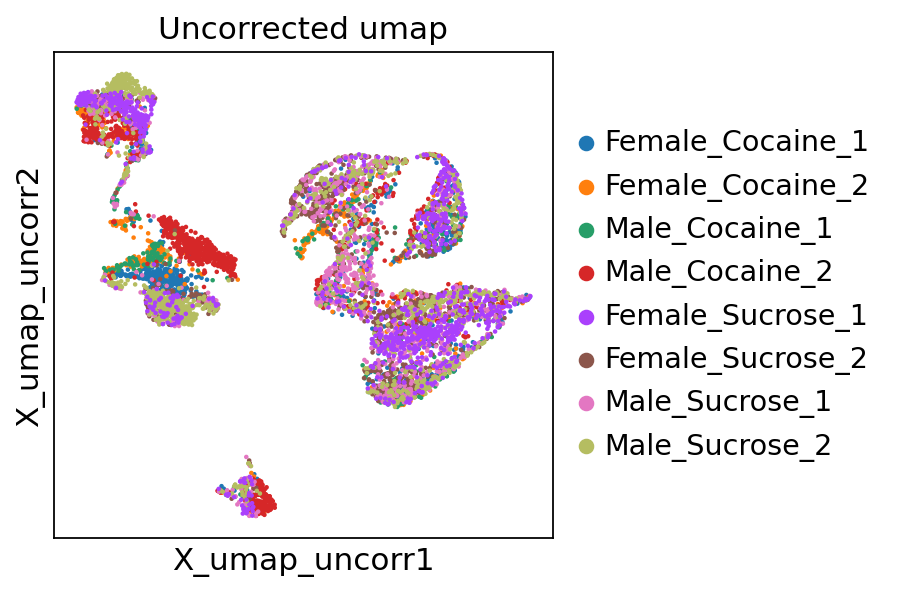

In [ ]:
sc.pl.embedding(adata, "X_umap_uncorr",color="sample", title="Uncorrected umap")

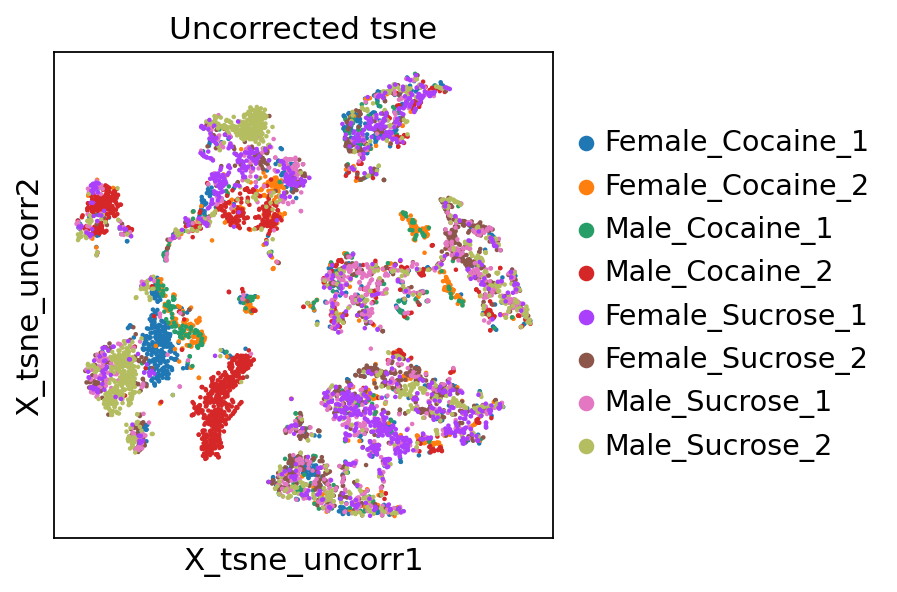

In [ ]:
sc.pl.embedding(adata, "X_tsne_uncorr", color="sample", title="Uncorrected tsne")

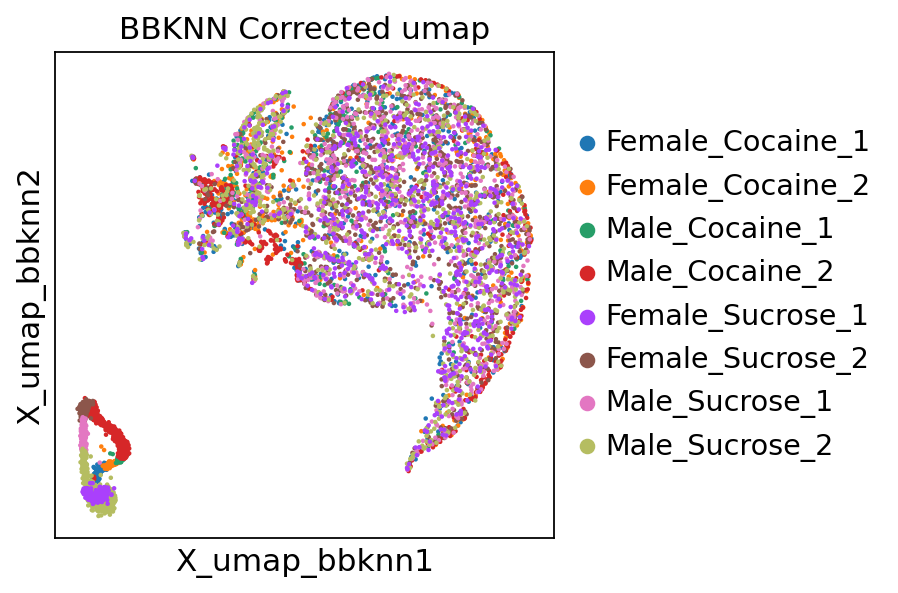

In [ ]:
sc.pl.embedding(adata, "X_umap_bbknn",color="sample", title="BBKNN Corrected umap")

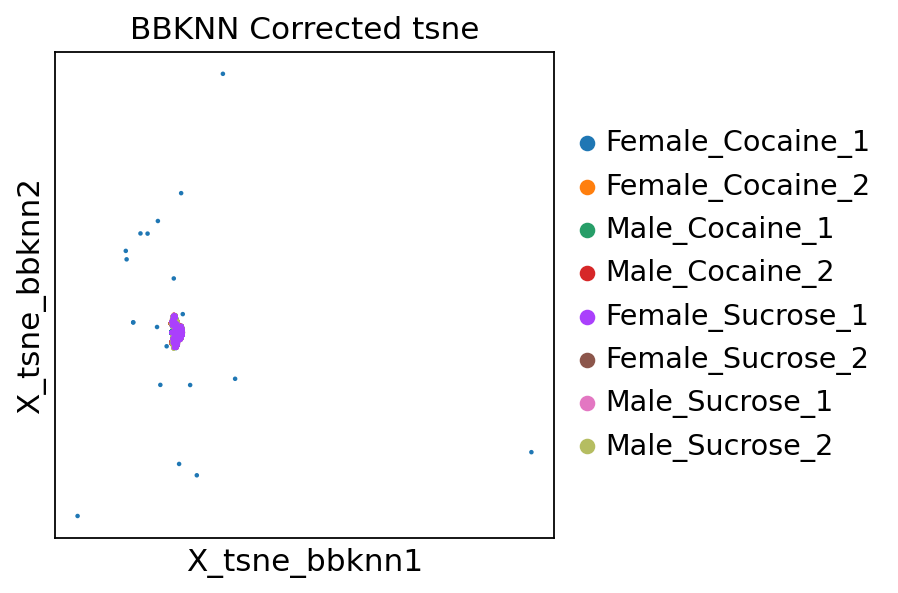

In [ ]:
sc.pl.embedding(adata, "X_tsne_bbknn",color="sample", title="BBKNN Corrected tsne")

In [ ]:
%%capture
!uv pip install harmonypy

In [ ]:
%%capture
# Install leidenalg and python-igraph for sc.tl.leiden
!uv pip install leidenalg python-igraph

In [ ]:
%%timeit
# harmony
import scanpy.external as sce
import harmonypy as hm

## KNOWN BUG:
# harmonypy==0.2.0 has a known bug described in https://github.com/slowkow/harmonypy/issues/49

## Actual function call to run harmony:
# sce.pp.harmony_integrate(adata, 'sample')

## Fix to get 'X_pca_harmony' of the correct shape:

# Extract PCs
_pcs = adata.obsm['X_pca'] # (n_cells, n_pcs)

# Run Harmony
_harmony_out = hm.run_harmony(_pcs, adata.obs, 'sample')

# Z_corr is already a numpy array with shape (n_cells, n_pcs)
adata.obsm['X_pca_harmony'] = _harmony_out.Z_corr

# Then we calculate a new umap and tsne.
# The previous PCA had 12 components, so X_pca_harmony also has 12. Adjust n_pcs accordingly.
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=12, use_rep='X_pca_harmony', random_state=159)
sc.tl.umap(adata, random_state=331)
sc.tl.tsne(adata, use_rep='X_pca_harmony', random_state=75)
sc.tl.leiden(adata, resolution=0.5, random_state=137)

2026-09-02 19:32:58,707 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-02 19:32:58,710 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-02 19:32:58,711 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-02 19:32:58,713 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-02 19:32:58,714 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-02 19:32:58,716 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-02 19:32:58,717 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-02 19:32:58,718 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-02 19:32:58,719 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-02 19:32:58,722 - harmonypy - INFO -     theta: [2. 2. 2

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:45)
running Leiden clustering
    finished: found 130 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


2026-09-02 19:35:08,243 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-02 19:35:08,247 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-02 19:35:08,250 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-02 19:35:08,254 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-02 19:35:08,258 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-02 19:35:08,259 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-02 19:35:08,260 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-02 19:35:08,262 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-02 19:35:08,264 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-02 19:35:08,266 - harmonypy - INFO -     theta: [2. 2. 2

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:25)
running Leiden clustering
    finished: found 130 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:03)


2026-09-02 19:36:51,676 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-02 19:36:51,679 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-02 19:36:51,681 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-02 19:36:51,682 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-02 19:36:51,684 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-02 19:36:51,686 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-02 19:36:51,688 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-02 19:36:51,690 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-02 19:36:51,692 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-02 19:36:51,694 - harmonypy - INFO -     theta: [2. 2. 2

...

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:28)
running Leiden clustering
    finished: found 130 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


2026-09-02 19:43:59,946 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-02 19:43:59,949 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-02 19:43:59,954 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-02 19:43:59,957 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-02 19:43:59,960 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-02 19:43:59,962 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-02 19:43:59,966 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-02 19:43:59,971 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-02 19:43:59,973 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-02 19:43:59,978 - harmonypy - INFO -     theta: [2. 2. 2

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:32)
running Leiden clustering
    finished: found 130 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


2026-09-02 19:45:48,791 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-02 19:45:48,793 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-02 19:45:48,794 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-02 19:45:48,796 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-02 19:45:48,797 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-02 19:45:48,798 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-02 19:45:48,799 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-02 19:45:48,801 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-02 19:45:48,802 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-02 19:45:48,803 - harmonypy - INFO -     theta: [2. 2. 2

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:12)
computing tSNE
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm)
    'tsne', tSNE parameters (adata.uns) (0:01:31)
running Leiden clustering
    finished: found 130 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)
1min 46s ± 2.45 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


<Axes: title={'center': 'Harmony umap'}, xlabel='UMAP1', ylabel='UMAP2'>

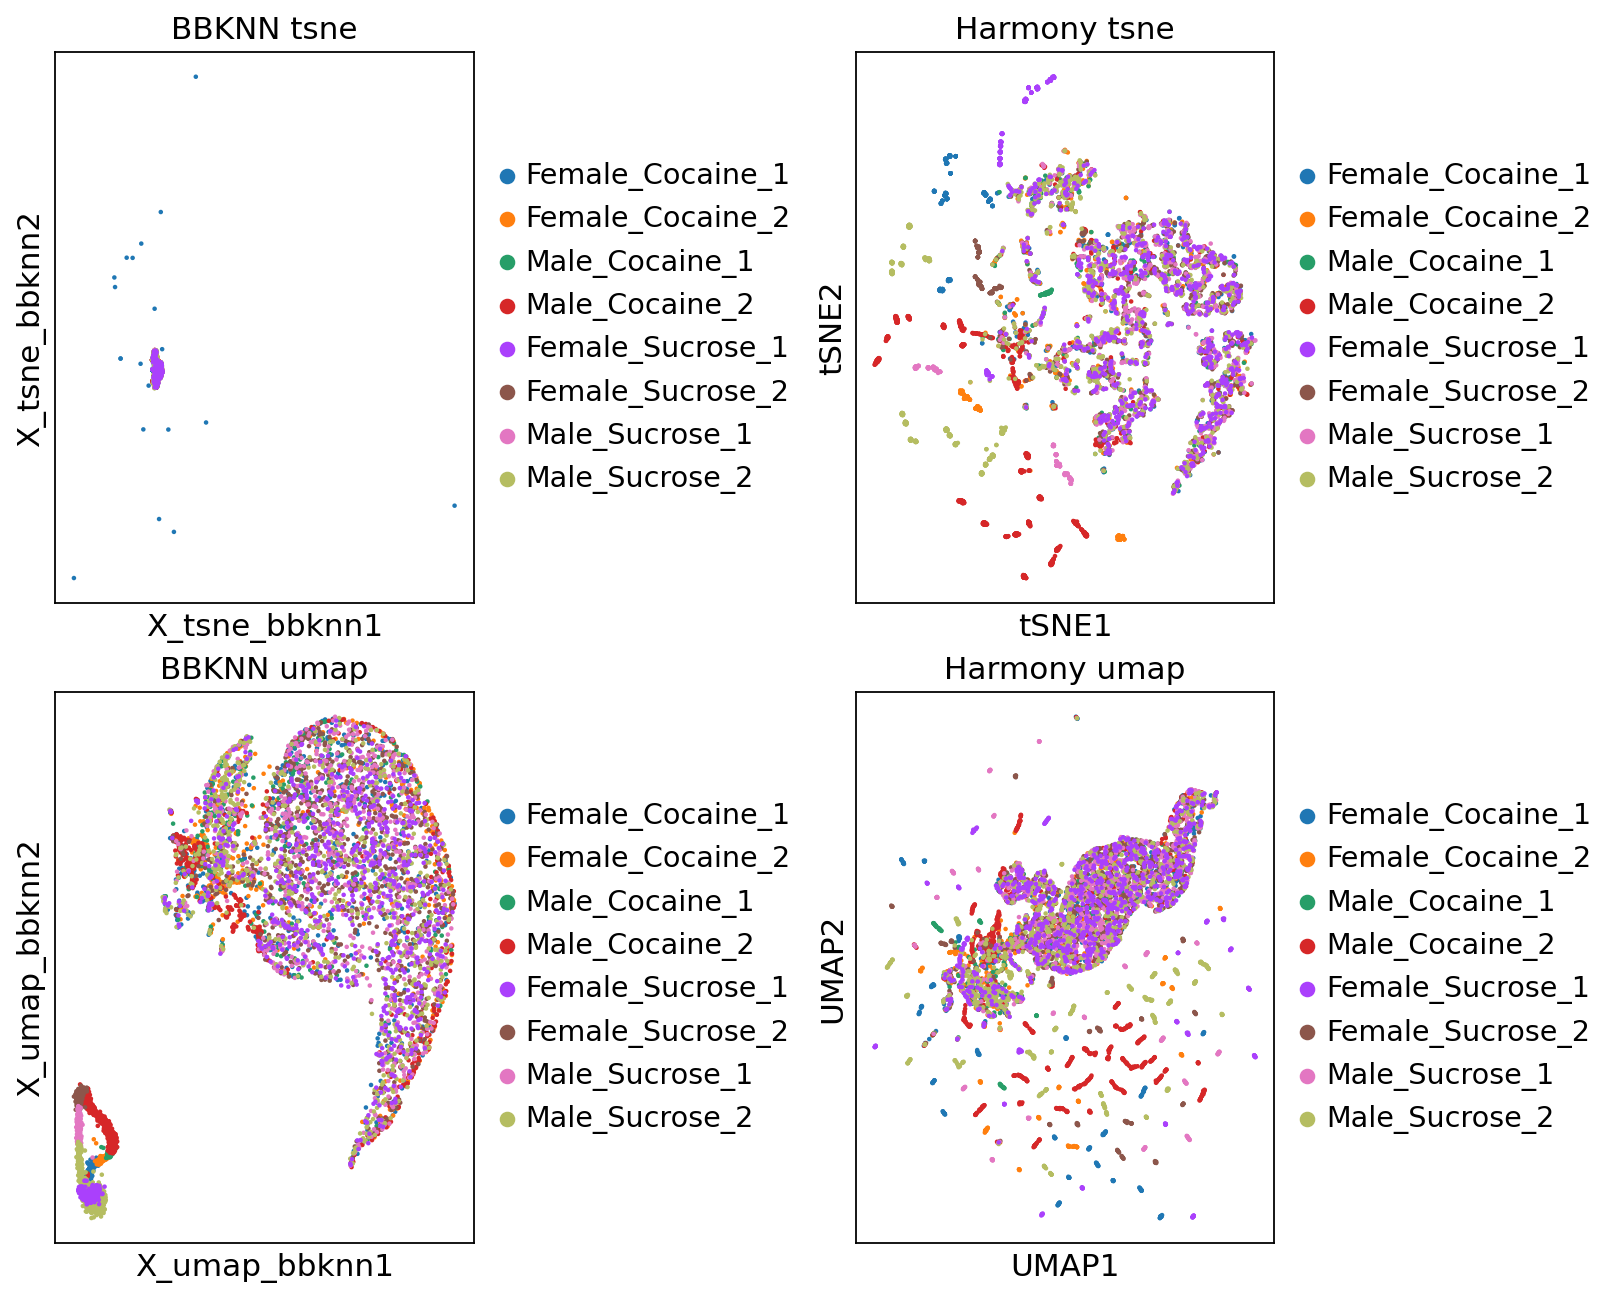

In [ ]:
# plot-harmony
fig, axs = plt.subplots(2, 2, figsize=(10,8),constrained_layout=True)
sc.pl.embedding(adata, 'X_tsne_bbknn', color="sample", title="BBKNN tsne", ax=axs[0,0], show=False)
sc.pl.tsne(adata, color="sample", title="Harmony tsne", ax=axs[0,1], show=False)
sc.pl.embedding(adata, 'X_umap_bbknn', color="sample", title="BBKNN umap", ax=axs[1,0], show=False)
sc.pl.umap(adata, color="sample", title="Harmony umap", ax=axs[1,1], show=False)

In [ ]:
  # save-harmony
# Store this umap and tsne with a new name.
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap']
adata.obsm['X_tsne_harmony'] = adata.obsm['X_tsne']

#save to file
save_file = '/content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated /harmony_integrated.h5ad'

# Ensure the directory exists before saving
import os
os.makedirs(os.path.dirname(save_file), exist_ok=True)

adata.write_h5ad(save_file)

In [ ]:
# combat
# create a new object with lognormalized counts
adata_combat = sc.AnnData(X=adata.raw.X, var=adata.raw.var, obs = adata.obs)

# first store the raw data
adata_combat.raw = adata_combat

# run combat
sc.pp.combat(adata_combat, key='sample')

Standardizing Data across genes.

Found 8 batches

Found 0 numerical variables:
	

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting data



In [ ]:
# process-combat
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d"%sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

NameError: name 'sc' is not defined

In [ ]:
# process-combat
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d"%sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

NameError: name 'sc' is not defined

In [ ]:
import scanpy as sc

# Ensure scanpy is imported and run your mentor's combat processing pipeline
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

ModuleNotFoundError: No module named 'scanpy'

In [ ]:
!pip install -q scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [ ]:
import scanpy as sc

# process-combat
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

NameError: name 'adata_combat' is not defined

In [ ]:
import scanpy as sc

# 1. Load your Drosophila preprocessed dataset
adata = sc.read_h5ad("data/filtered/drosophila_file.h5ad")

# 2. Make a copy and run ComBat batch correction on your 'sample' metadata
adata_combat = adata.copy()
sc.pp.combat(adata_combat, key='sample')

# 3. Process ComBat object (Mentor's pathway)
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

print("\n--- ComBat processing completed successfully! ---")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'data/filtered/drosophila_file.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import scanpy as sc

# 1. Load using full Google Drive path
drive_path = ""
adata = sc.read_h5ad(drive_path)

# 2. Make a copy and run ComBat batch correction on 'sample' metadata
adata_combat = adata.copy()
sc.pp.combat(adata_combat, key='sample')

# 3. Process ComBat object (Mentor's pathway)
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

print("\n--- ComBat processing completed successfully! ---")

In [ ]:
import scanpy as sc

# 1. Load using full Google Drive path
drive_path = ""
adata = sc.read_h5ad(drive_path)

# 2. Make a copy and run ComBat batch correction on 'sample' metadata
adata_combat = adata.copy()
sc.pp.combat(adata_combat, key='sample')

# 3. Process ComBat object (Mentor's pathway)
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

print("\n--- ComBat processing completed successfully! ---")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [11]:
import scanpy as sc

# 1. Load using full Google Drive path
drive_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad "
adata = sc.read_h5ad(drive_path)

# 2. Make a copy and run ComBat batch correction on 'sample' metadata
adata_combat = adata.copy()
sc.pp.combat(adata_combat, key='sample')

# 3. Process ComBat object (Mentor's pathway)
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)

sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

print("\n--- ComBat processing completed successfully! ---")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/drosophila_scRNAseq_project/data /filtered/drosophila_qc_preprocessed.h5ad ', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [12]:
import os

# Search locations for drosophila_file.h5ad
search_paths = [
    "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad",
    "/content/drive/MyDrive/drosophila_scRNAseq_project/data/raw/data/filtered/drosophila_file.h5ad",
    "data/filtered/drosophila_file.h5ad"
]

print("--- Searching for file ---")
found = False
for path in search_paths:
    if os.path.exists(path):
        print(f"FOUND FILE AT: {path}")
        found = True

if not found:
    print("File not found in expected folders. Searching entire Google Drive...")
    for root, dirs, files in os.walk("/content/drive/MyDrive/"):
        if "drosophila_file.h5ad" in files:
            print(f"FOUND FILE AT: {os.path.join(root, 'drosophila_file.h5ad')}")
            found = True

if not found:
    print("\nFile missing! You need to re-run your previous filtering step and save it:")
    print("adata.write_h5ad('/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad')")

--- Searching for file ---
File not found in expected folders. Searching entire Google Drive...
FOUND FILE AT: /content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/data/filtered/drosophila_file.h5ad


Successfully moved file to: /content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad
Highly variable genes: 307


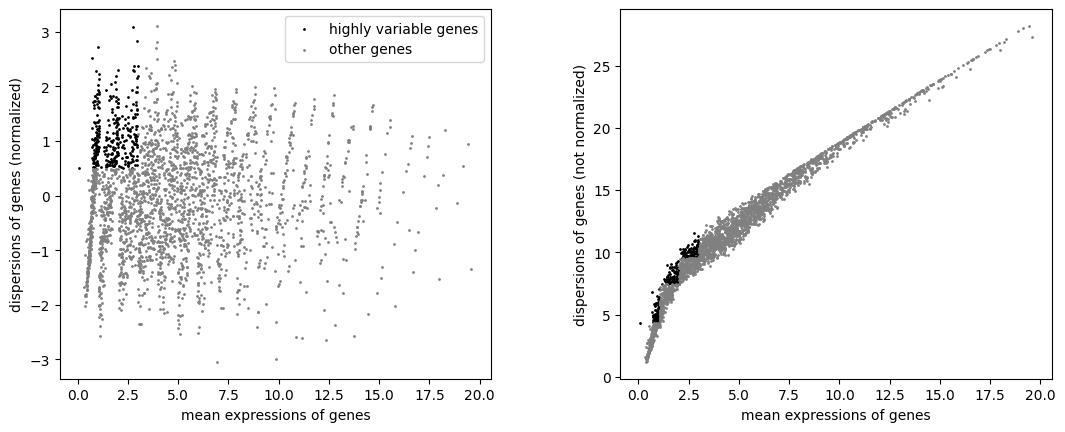

/tmp/ipykernel_1371/1071410489.py:28: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)



--- ComBat processing completed successfully! ---


In [13]:
import os
import shutil
import scanpy as sc

# 1. Define source (where the file currently is) and target (where it should be)
old_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /raw/data/filtered/drosophila_file.h5ad"
target_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered"
clean_path = os.path.join(target_dir, "drosophila_file.h5ad")

# Create target directory if needed and move the file
os.makedirs(target_dir, exist_ok=True)
if os.path.exists(old_path):
    shutil.move(old_path, clean_path)
    print(f"Successfully moved file to: {clean_path}")

# 2. Load dataset from the correct location
adata = sc.read_h5ad(clean_path)

# 3. Create combat copy and run batch correction
adata_combat = adata.copy()
sc.pp.combat(adata_combat, key='sample')

# 4. Downstream processing (HVG, PCA, Neighbors, UMAP, t-SNE)
sc.pp.highly_variable_genes(adata_combat)
print("Highly variable genes: %d" % sum(adata_combat.var.highly_variable))
sc.pl.highly_variable_genes(adata_combat)

sc.pp.pca(adata_combat, n_comps=30, use_highly_variable=True, svd_solver='arpack', random_state=573)
sc.pp.neighbors(adata_combat, random_state=159)

sc.tl.umap(adata_combat, random_state=331)
sc.tl.tsne(adata_combat, random_state=75)

print("\n--- ComBat processing completed successfully! ---")

In [14]:
# hvg-combat
# compare var_genes
var_genes_combat = adata_combat.var.highly_variable
print("With all data %d"%sum(var_genes_all))
print("With combat %d"%sum(var_genes_combat))
print("Overlap %d"%sum(var_genes_all & var_genes_combat))

print("With 2 batches %d"%sum(var_select))
print("Overlap %d"%sum(var_genes_combat & var_select))

NameError: name 'var_genes_all' is not defined

In [15]:
# plot-combat
fig, axs = plt.subplots(2, 2, figsize=(10,8),constrained_layout=True)
sc.pl.tsne(adata, color="sample", title="Harmony tsne", ax=axs[0,0], show=False)
sc.pl.tsne(adata_combat, color="sample", title="Combat tsne", ax=axs[0,1], show=False)
sc.pl.umap(adata, color="sample", title="Harmony umap", ax=axs[1,0], show=False)
sc.pl.umap(adata_combat, color="sample", title="Combat umap", ax=axs[1,1], show=False)

NameError: name 'plt' is not defined

In [16]:
# 1. Ensure HVGs are calculated on your uncorrected raw adata object
if 'highly_variable' not in adata.var:
    sc.pp.highly_variable_genes(adata)

# 2. Extract logical boolean masks for HVGs
var_genes_all = adata.var['highly_variable']
var_genes_combat = adata_combat.var['highly_variable']

# 3. Compare uncorrected vs. ComBat corrected highly variable genes
print("With all data: %d" % sum(var_genes_all))
print("With combat: %d" % sum(var_genes_combat))
print("Overlap: %d" % sum(var_genes_all & var_genes_combat))

With all data: 2595
With combat: 307
Overlap: 307


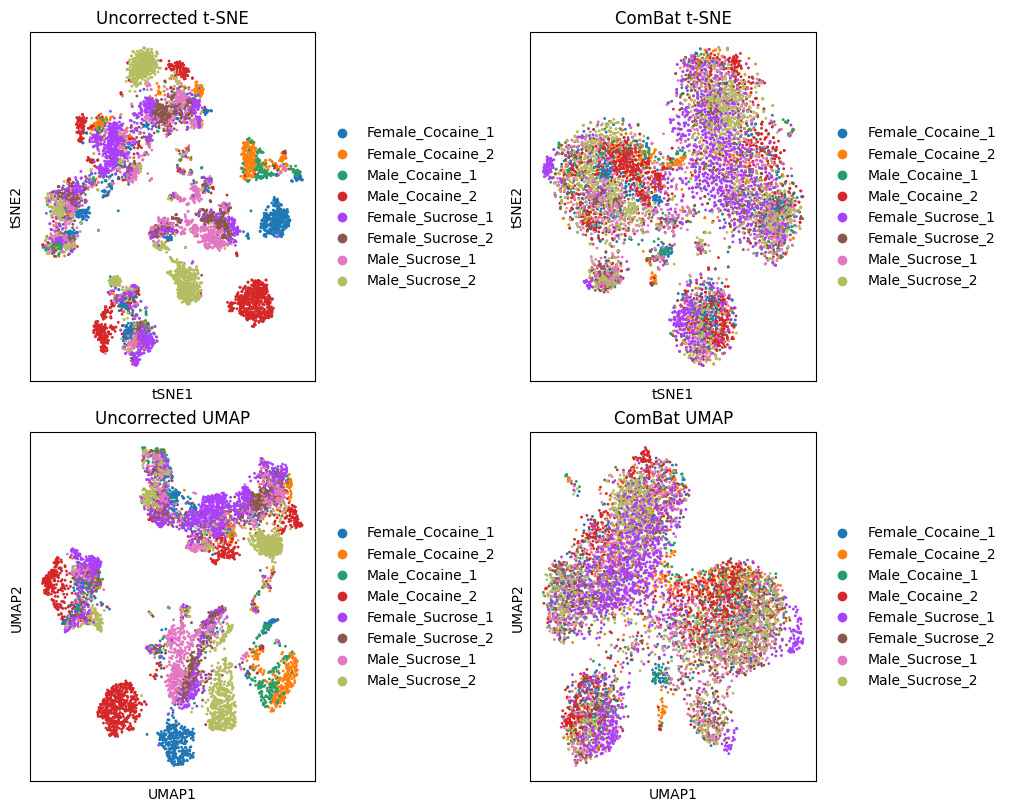

In [17]:
import matplotlib.pyplot as plt

# 1. Ensure UMAP and t-SNE are calculated on raw adata if not already done
if 'X_umap' not in adata.obsm:
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
if 'X_tsne' not in adata.obsm:
    sc.tl.tsne(adata)

# 2. Plot Uncorrected vs. ComBat comparison
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

sc.pl.tsne(adata, color="sample", title="Uncorrected t-SNE", ax=axs[0, 0], show=False)
sc.pl.tsne(adata_combat, color="sample", title="ComBat t-SNE", ax=axs[0, 1], show=False)

sc.pl.umap(adata, color="sample", title="Uncorrected UMAP", ax=axs[1, 0], show=False)
sc.pl.umap(adata_combat, color="sample", title="ComBat UMAP", ax=axs[1, 1], show=False)

plt.show()

In [18]:
# save-combat
# Add the dimred to the other adata object
adata.obsm['X_umap_combat'] = adata_combat.obsm['X_umap']
adata.obsm['X_tsne_combat'] = adata_combat.obsm['X_tsne']
adata.obsm['X_pca_combat'] = adata_combat.obsm['X_pca']

#save to file
save_file = '/content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated '
adata_combat.write_h5ad(save_file)

IsADirectoryError: [Errno 21] Unable to synchronously create file (unable to open file: name = '/content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated ', errno = 21, error message = 'Is a directory', flags = 13, o_flags = 242)

In [19]:
import os

# 1. Transfer ComBat dimensionality reduction coordinates to main adata object
adata.obsm['X_umap_combat'] = adata_combat.obsm['X_umap']
adata.obsm['X_tsne_combat'] = adata_combat.obsm['X_tsne']
adata.obsm['X_pca_combat'] = adata_combat.obsm['X_pca']

# 2. Set clean output directory
integrated_dir = '/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated'
os.makedirs(integrated_dir, exist_ok=True)

# 3. Define clear file paths
combat_file = os.path.join(integrated_dir, 'drosophila_combat_integrated.h5ad')
combined_file = os.path.join(integrated_dir, 'drosophila_file_integrated.h5ad')

# 4. Save both AnnData objects
adata_combat.write_h5ad(combat_file)
print(f"Saved ComBat object to: {combat_file}")

adata.write_h5ad(combined_file)
print(f"Saved combined object to: {combined_file}")

Saved ComBat object to: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_combat_integrated.h5ad
Saved combined object to: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_file_integrated.h5ad


In [20]:
%%capture
!uv pip install scanorama

In [21]:
%%timeit
# prep-scanorama
# split per batch into new objects.
batches = adata.obs['sample'].cat.categories.tolist()
alldata = {}
for batch in batches:
    alldata[batch] = adata[adata.obs['sample'] == batch,]

alldata

62 ms ± 10.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [22]:
# scanorama
import scanorama

#subset the individual dataset to the variable genes we defined at the beginning
alldata2 = dict()
for ds in alldata.keys():
    print(ds)
    alldata2[ds] = alldata[ds][:,var_genes]

#convert to list of AnnData objects
adatas = list(alldata2.values())

# run scanorama.integrate
scanorama.integrate_scanpy(adatas, dimred = 50)

NameError: name 'alldata' is not defined

In [23]:
import scanorama

# 1. Ensure highly variable genes are calculated on main adata
if 'highly_variable' not in adata.var:
    sc.pp.highly_variable_genes(adata)

var_genes = adata.var['highly_variable']

# 2. Re-create the 'alldata' dictionary by splitting adata by sample
alldata = {sample: adata[adata.obs['sample'] == sample].copy() for sample in adata.obs['sample'].unique()}

# 3. Subset each individual dataset to the highly variable genes
alldata2 = dict()
for ds in alldata.keys():
    print(f"Subsetting: {ds}")
    alldata2[ds] = alldata[ds][:, var_genes]

# 4. Convert to list of AnnData objects and run Scanorama
adatas = list(alldata2.values())
scanorama.integrate_scanpy(adatas, dimred=50)

print("\n--- Scanorama integration complete! ---")

Subsetting: Female_Cocaine_1
Subsetting: Female_Cocaine_2
Subsetting: Male_Cocaine_1
Subsetting: Male_Cocaine_2
Subsetting: Female_Sucrose_2
Subsetting: Male_Sucrose_1
Subsetting: Male_Sucrose_2
Subsetting: Female_Sucrose_1
Found 2595 genes among all datasets
[[0.         0.51351351 0.53638814 0.36313364 0.50859107 0.42382589
  0.19014891 0.33447881]
 [0.         0.         0.74662162 0.34797297 0.36993243 0.40371622
  0.18243243 0.38719212]
 [0.         0.         0.         0.24528302 0.57412399 0.50673854
  0.25606469 0.38005391]
 [0.         0.         0.         0.         0.14746544 0.240553
  0.33824885 0.19078341]
 [0.         0.         0.         0.         0.         0.81003584
  0.27688172 0.76453202]
 [0.         0.         0.         0.         0.         0.
  0.59700176 0.78916256]
 [0.         0.         0.         0.         0.         0.
  0.         0.33793103]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]
Processing datasets (

/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, ini


--- Scanorama integration complete! ---


/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred
/usr/local/lib/python3.13/dist-packages/scanorama/scanorama.py:284: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm['X_scanorama'] = X_dimred


In [24]:
# scanorama-output
#scanorama adds the corrected matrix to adata.obsm in each of the datasets in adatas.
adatas[0].obsm['X_scanorama'].shape

(873, 50)

In [25]:
# scanorama-merge
# Get all the integrated matrices.
scanorama_int = [ad.obsm['X_scanorama'] for ad in adatas]

# make into one matrix.
all_s = np.concatenate(scanorama_int)
print(all_s.shape)

# add to the AnnData object, create a new object first
adata.obsm["Scanorama"] = all_s

NameError: name 'np' is not defined

In [26]:
import numpy as np

# 1. Concatenate Scanorama integrated matrices
all_s = np.concatenate([ad.obsm['X_scanorama'] for ad in adatas])
print(f"Scanorama matrix shape: {all_s.shape}")

# 2. Re-concatenate the split AnnData objects so cell order stays aligned
adata_scanorama = adatas[0].concatenate(adatas[1:], batch_key='concat_batch')

# 3. Store the integrated embeddings directly into the re-aligned AnnData object
adata_scanorama.obsm["X_scanorama"] = all_s
adata.obsm["X_scanorama"] = adata_scanorama.obsm["X_scanorama"]

print("Scanorama embeddings successfully merged and added to adata!")

Scanorama matrix shape: (7229, 50)


AttributeError: 'AnnData' object has no attribute 'concatenate'

In [27]:
import numpy as np
import anndata as ad

# 1. Concatenate Scanorama integrated matrices
all_s = np.concatenate([a.obsm['X_scanorama'] for a in adatas])
print(f"Scanorama matrix shape: {all_s.shape}")

# 2. Combine the split AnnData objects using modern anndata syntax
adata_scanorama = ad.concat(adatas, label='scanorama_batch')

# 3. Store integrated embeddings in the combined Scanorama object
adata_scanorama.obsm["X_scanorama"] = all_s

# 4. Map coordinates back to your primary adata object safely
adata.obsm["X_scanorama"] = adata_scanorama[adata.obs_names].obsm["X_scanorama"]

print("Scanorama embeddings successfully assigned!")

Scanorama matrix shape: (7229, 50)
Scanorama embeddings successfully assigned!


In [28]:
# process-scanorama
# tsne and umap
sc.pp.neighbors(adata, n_pcs =30, use_rep = "Scanorama", random_state=159)
sc.tl.umap(adata, random_state=331)
sc.tl.tsne(adata, n_pcs = 30, use_rep = "Scanorama", random_state=75)

ValueError: Did not find Scanorama in `.obsm.keys()`. You need to compute it first.

In [29]:
# process-scanorama
# Compute neighbors, UMAP, and t-SNE using the stored X_scanorama representation
sc.pp.neighbors(adata, n_pcs=30, use_rep="X_scanorama", random_state=159)
sc.tl.umap(adata, random_state=331)
sc.tl.tsne(adata, n_pcs=30, use_rep="X_scanorama", random_state=75)

print("Scanorama neighbors, UMAP, and t-SNE calculated successfully!")

Scanorama neighbors, UMAP, and t-SNE calculated successfully!


KeyError: "Could not find 'X_tsne_harmony' or 'X_X_tsne_harmony' in .obsm"

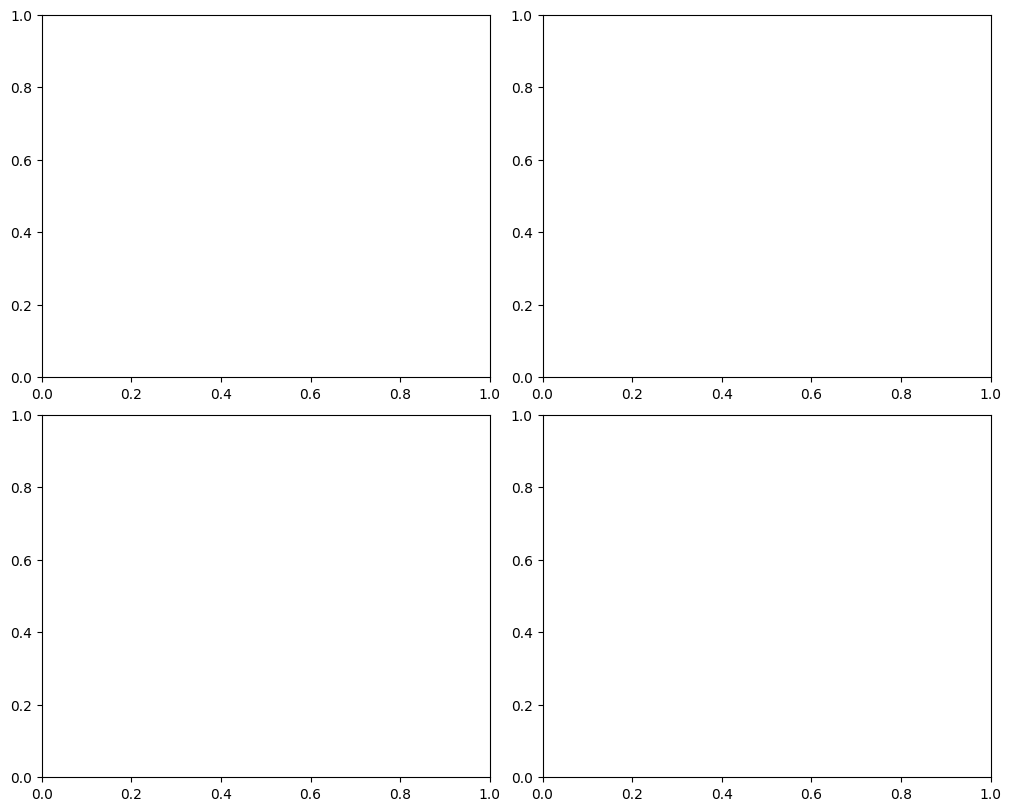

In [30]:
# plot-scanorama
fig, axs = plt.subplots(2, 2, figsize=(10,8),constrained_layout=True)
sc.pl.embedding(adata, 'X_tsne_harmony', color="sample", title="Harmony tsne", ax=axs[0,0], show=False)
sc.pl.tsne(adata, color="sample", title="Scanorama tsne", ax=axs[0,1], show=False)
sc.pl.embedding(adata, 'X_umap_harmony', color="sample", title="Harmony umap", ax=axs[1,0], show=False)
sc.pl.umap(adata, color="sample", title="Scanorama umap", ax=axs[1,1], show=False)

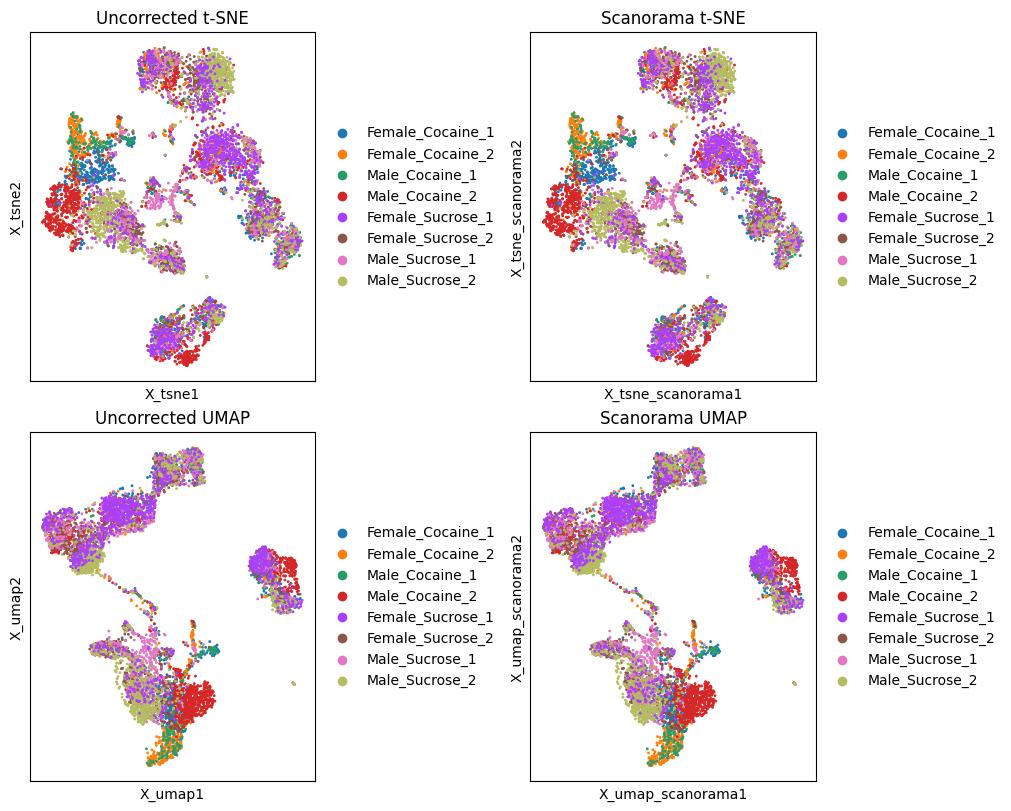

In [31]:
import matplotlib.pyplot as plt

# 1. Save Scanorama coordinates to dedicated keys in obsm
adata.obsm['X_umap_scanorama'] = adata.obsm['X_umap'].copy()
adata.obsm['X_tsne_scanorama'] = adata.obsm['X_tsne'].copy()

# 2. Plot Uncorrected vs. Scanorama comparison
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# Top Row: t-SNE Comparison
sc.pl.embedding(adata, basis='X_tsne', color="sample", title="Uncorrected t-SNE", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_tsne_scanorama', color="sample", title="Scanorama t-SNE", ax=axs[0, 1], show=False)

# Bottom Row: UMAP Comparison
sc.pl.embedding(adata, basis='X_umap', color="sample", title="Uncorrected UMAP", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama UMAP", ax=axs[1, 1], show=False)

plt.show()

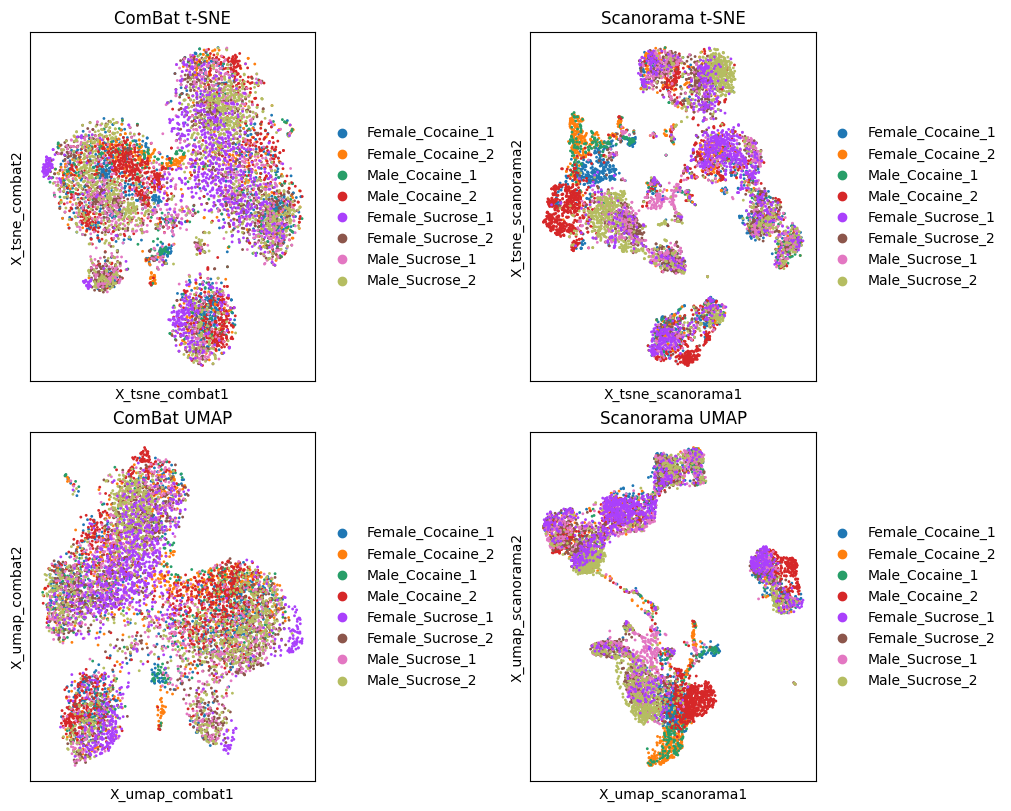

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# t-SNE Comparison
sc.pl.embedding(adata, basis='X_tsne_combat', color="sample", title="ComBat t-SNE", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_tsne_scanorama', color="sample", title="Scanorama t-SNE", ax=axs[0, 1], show=False)

# UMAP Comparison
sc.pl.embedding(adata, basis='X_umap_combat', color="sample", title="ComBat UMAP", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama UMAP", ax=axs[1, 1], show=False)

plt.show()

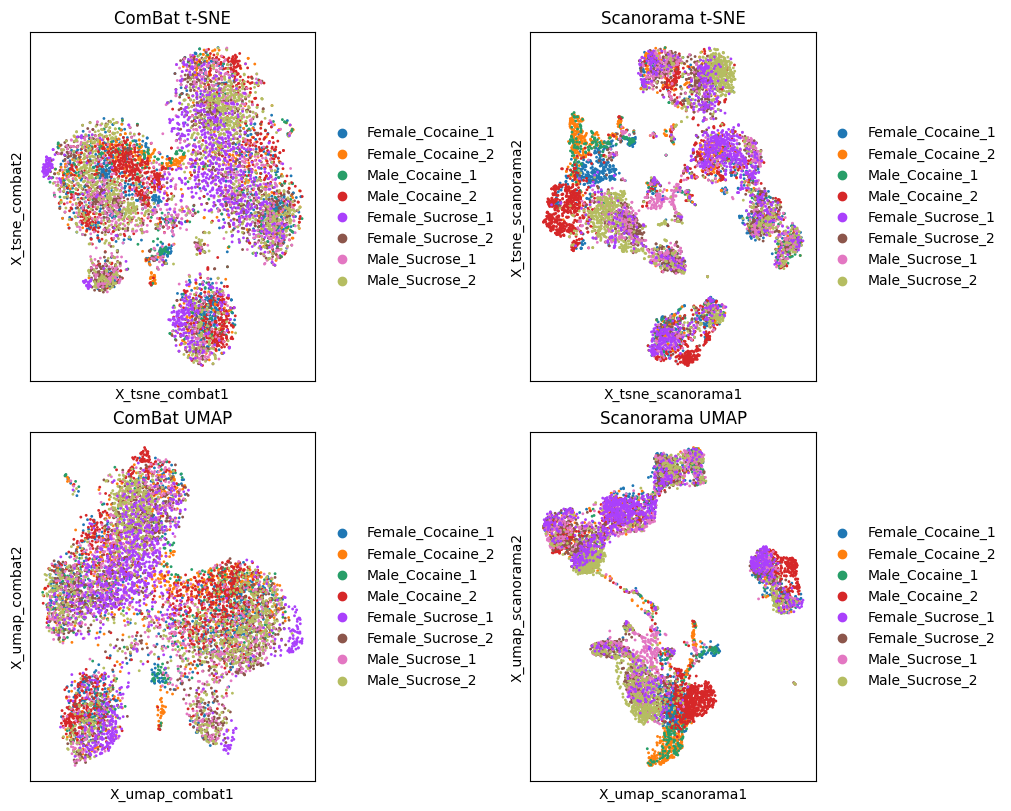

In [34]:
import warnings
import matplotlib.pyplot as plt

# Filter out matplotlib/scanpy UserWarnings to keep output clean
warnings.filterwarnings('ignore')

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# t-SNE Comparison
sc.pl.embedding(adata, basis='X_tsne_combat', color="sample", title="ComBat t-SNE", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_tsne_scanorama', color="sample", title="Scanorama t-SNE", ax=axs[0, 1], show=False)

# UMAP Comparison
sc.pl.embedding(adata, basis='X_umap_combat', color="sample", title="ComBat UMAP", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama UMAP", ax=axs[1, 1], show=False)

plt.show()

In [35]:
import os

integrated_dir = '/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated'
os.makedirs(integrated_dir, exist_ok=True)

scanorama_file = os.path.join(integrated_dir, 'drosophila_scanorama_integrated.h5ad')
adata.write_h5ad(scanorama_file)

print(f"Saved integrated object with Scanorama and ComBat embeddings to:\n{scanorama_file}")

Saved integrated object with Scanorama and ComBat embeddings to:
/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad


KeyError: "Could not find 'X_umap_uncorr' or 'X_X_umap_uncorr' in .obsm"

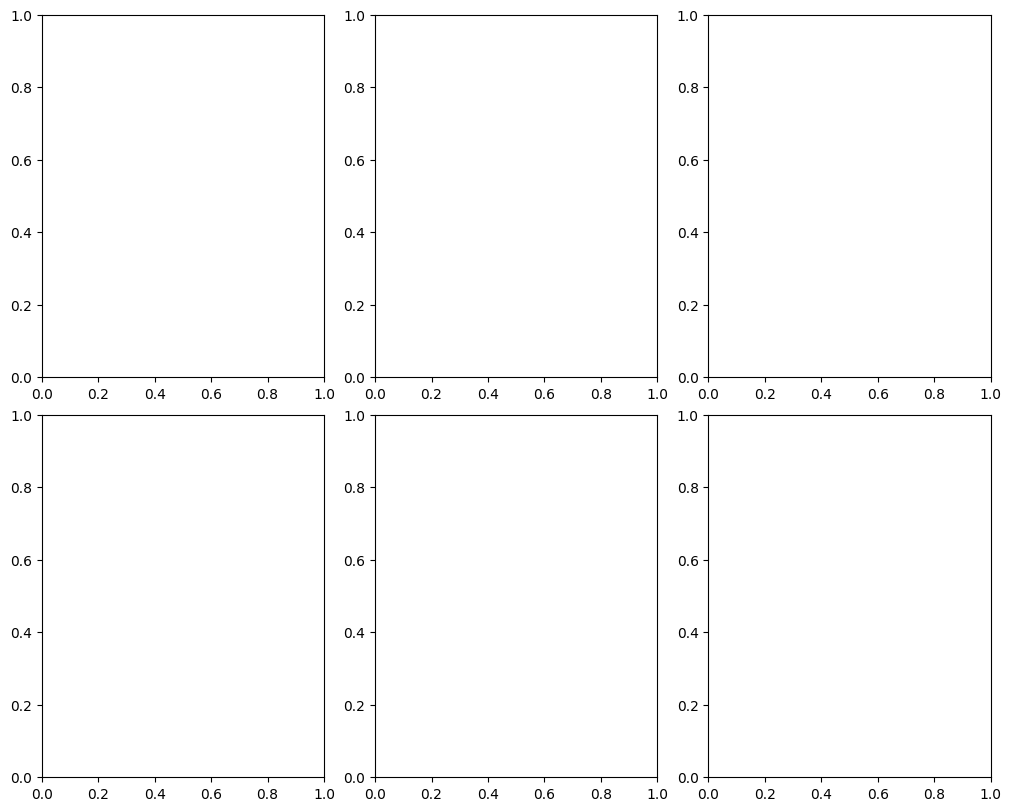

In [36]:
# plot-all
fig, axs = plt.subplots(2, 3, figsize=(10,8),constrained_layout=True)
sc.pl.embedding(adata, 'X_umap_uncorr', color="sample", title="Uncorrected", ax=axs[0,0], show=False)
sc.pl.embedding(adata, 'X_umap_bbknn', color="sample", title="BBKNN", ax=axs[0,1], show=False)
sc.pl.umap(adata_combat, color="sample", title="Combat", ax=axs[0,2], show=False)
sc.pl.embedding(adata, 'X_umap_harmony', color="sample", title="Harmony", ax=axs[1,0], show=False)
sc.pl.umap(adata, color="sample", title="Scanorama", ax=axs[1,1], show=False)

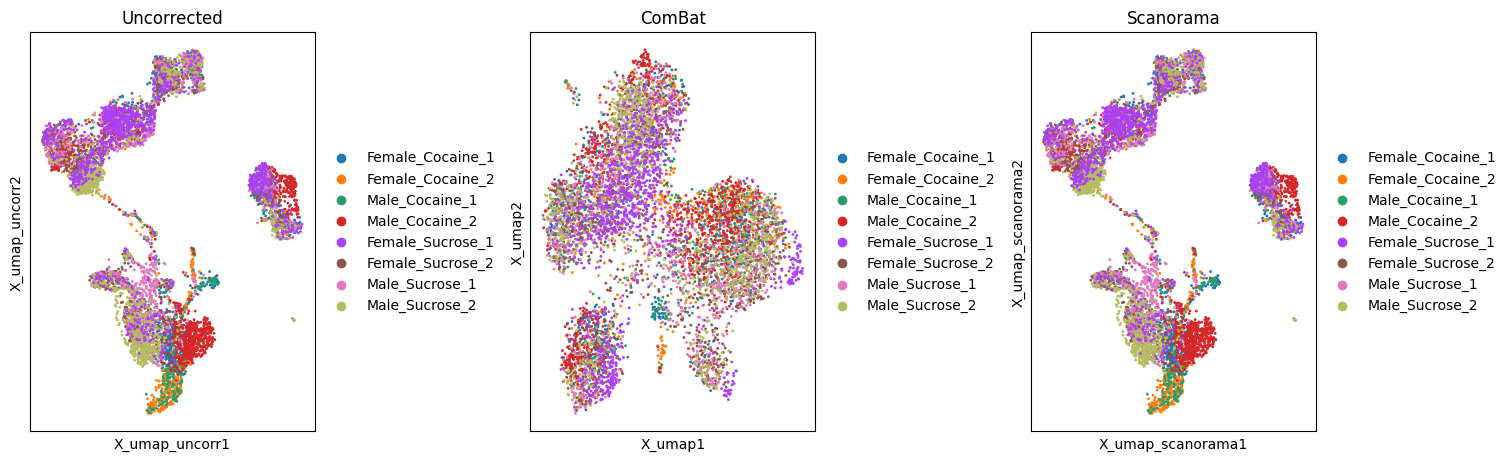

In [37]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 1. Ensure uncorrected key exists explicitly in obsm
if 'X_umap_uncorr' not in adata.obsm and 'X_umap' in adata.obsm:
    adata.obsm['X_umap_uncorr'] = adata.obsm['X_umap'].copy()

# 2. Plot available embeddings (Uncorrected, ComBat, Scanorama)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

sc.pl.embedding(adata, basis='X_umap_uncorr', color="sample", title="Uncorrected", ax=axs[0], show=False)
sc.pl.embedding(adata_combat, basis='X_umap', color="sample", title="ComBat", ax=axs[1], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama", ax=axs[2], show=False)

plt.show()

In [38]:
# Optional: Compute BBKNN and Harmony if required by your pipeline

# BBKNN
import bbknn
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)
adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap'].copy()

# Harmony
import scanpy.external as sce
sce.pp.harmony_integrate(adata, key='sample')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

ModuleNotFoundError: No module named 'bbknn'

In [39]:
# 1. Install missing integration packages
!pip install -q bbknn harmony-pytorch

import warnings
import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce
import bbknn

warnings.filterwarnings('ignore')

# --- PREPARE ALL INTEGRATION EMBEDDINGS ---

# A. Uncorrected
if 'X_umap_uncorr' not in adata.obsm:
    adata.obsm['X_umap_uncorr'] = adata.obsm['X_umap'].copy()

# B. BBKNN
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)
adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap'].copy()

# C. Harmony
sce.pp.harmony_integrate(adata, key='sample')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

# --- PLOT 2x3 GRID ---

fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

sc.pl.embedding(adata, basis='X_umap_uncorr', color="sample", title="Uncorrected", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_bbknn', color="sample", title="BBKNN", ax=axs[0, 1], show=False)
sc.pl.embedding(adata_combat, basis='X_umap', color="sample", title="ComBat", ax=axs[0, 2], show=False)
sc.pl.embedding(adata, basis='X_umap_harmony', color="sample", title="Harmony", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama", ax=axs[1, 1], show=False)

# Hide unused sub-plot tile (bottom-right)
axs[1, 2].axis('off')

plt.show()

ModuleNotFoundError: No module named 'harmonypy'

In [40]:
# 1. Install harmonypy
!pip install -q harmonypy bbknn

import warnings
import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce
import bbknn

warnings.filterwarnings('ignore')

# --- PREPARE ALL INTEGRATION EMBEDDINGS ---

# A. Uncorrected
if 'X_umap_uncorr' not in adata.obsm:
    adata.obsm['X_umap_uncorr'] = adata.obsm['X_umap'].copy()

# B. BBKNN
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)
adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap'].copy()

# C. Harmony
sce.pp.harmony_integrate(adata, key='sample')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

# --- PLOT 2x3 GRID ---

fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

sc.pl.embedding(adata, basis='X_umap_uncorr', color="sample", title="Uncorrected", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_bbknn', color="sample", title="BBKNN", ax=axs[0, 1], show=False)
sc.pl.embedding(adata_combat, basis='X_umap', color="sample", title="ComBat", ax=axs[0, 2], show=False)
sc.pl.embedding(adata, basis='X_umap_harmony', color="sample", title="Harmony", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama", ax=axs[1, 1], show=False)

# Hide the empty 6th subplot tile
axs[1, 2].axis('off')

plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 13.8 MB/s eta 0:00:00


2026-09-03 08:01:55,693 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-03 08:01:55,696 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-03 08:01:55,699 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-03 08:01:55,700 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-03 08:01:55,703 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-03 08:01:55,705 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-03 08:01:55,707 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-03 08:01:55,708 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-03 08:01:55,710 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-03 08:01:55,713 - harmonypy - INFO -     theta: [2. 2. 2

ValueError: Value passed for key 'X_pca_harmony' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (50,) while it should have had (7229,).

In [41]:
!pip install -q harmonypy bbknn

import warnings
import matplotlib.pyplot as plt
import scanpy as sc
import scanpy.external as sce
import bbknn

warnings.filterwarnings('ignore')

# --- 1. PREPARE PCA & UNCORRECTED UMAP ---
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
adata.obsm['X_umap_uncorr'] = adata.obsm['X_umap'].copy()

# --- 2. RUN BBKNN ---
bbknn.bbknn(adata, batch_key='sample')
sc.tl.umap(adata)
adata.obsm['X_umap_bbknn'] = adata.obsm['X_umap'].copy()

# --- 3. RUN HARMONY ---
sce.pp.harmony_integrate(adata, key='sample', basis='X_pca', adjusted_basis='X_pca_harmony')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

# --- 4. PLOT COMPLETE 2x3 GRID ---
fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

sc.pl.embedding(adata, basis='X_umap_uncorr', color="sample", title="Uncorrected", ax=axs[0, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_bbknn', color="sample", title="BBKNN", ax=axs[0, 1], show=False)
sc.pl.embedding(adata_combat, basis='X_umap', color="sample", title="ComBat", ax=axs[0, 2], show=False)
sc.pl.embedding(adata, basis='X_umap_harmony', color="sample", title="Harmony", ax=axs[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_scanorama', color="sample", title="Scanorama", ax=axs[1, 1], show=False)

# Hide empty 6th tile
axs[1, 2].axis('off')

plt.show()

2026-09-03 08:03:41,500 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-03 08:03:41,503 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-03 08:03:41,505 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-03 08:03:41,510 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-03 08:03:41,512 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-03 08:03:41,515 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-03 08:03:41,515 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-03 08:03:41,517 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-03 08:03:41,519 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-03 08:03:41,521 - harmonypy - INFO -     theta: [2. 2. 2

ValueError: Value passed for key 'X_pca_harmony' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (30,) while it should have had (7229,).

In [42]:
import scanpy as sc

# 1. Choose the cluster key you calculated (leiden_res_0.8 or leiden_0.6)
cluster_key = "leiden_res_0.8" if "leiden_res_0.8" in adata.obs else "leiden_0.6"

# 2. Select target clusters (e.g., clusters '1', '2', '4', '8')
target_clusters = ['1', '2', '4', '8']

# Filter to keep only target clusters present in the dataset
available_clusters = [c for c in target_clusters if c in adata.obs[cluster_key].unique()]

# 3. Subset AnnData directly
sub_adata = adata[adata.obs[cluster_key].isin(available_clusters), :].copy()

print(f"Subsetted {sub_adata.n_obs} cells from clusters: {available_clusters}")

# 4. View sample counts for the subsetted cells
print("\nSample counts in subset:")
print(sub_adata.obs["sample"].value_counts())

KeyError: 'leiden_0.6'